In [67]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import random
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [68]:
print("--- LOADING PROCESSED DATA ---")

load_path = "./processed_data/processed_videos"
videos = pd.read_csv(load_path)

print(f"{len(videos)} videos loaded!")
pd.set_option('display.max_colwidth', None)
display(videos.sample(15))

--- LOADING PROCESSED DATA ---
7000 videos loaded!


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution
5263,752_751.mp4,1,NeuralTextures,classic_752,classic_751,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/752_751.mp4,331,30.0,11.033333,720x720
1558,299_145.mp4,1,Deepfakes,classic_299,classic_145,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/299_145.mp4,314,15.0,20.933333,480x480
3792,913_893.mp4,1,FaceShifter,classic_913,classic_893,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/913_893.mp4,634,30.0,21.133333,480x480
5630,036_035.mp4,1,NeuralTextures,classic_036,classic_035,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/036_035.mp4,337,25.0,13.480000,480x480
2242,811.mp4,0,original,classic_811,classic_811,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/811.mp4,542,25.0,21.680000,720x720
442,07_03__talking_against_wall__IFSURI9X.mp4,1,DeepFakeDetection,dfd_07,dfd_03,talking_against_wall,IFSURI9X,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/07_03__talking_against_wall__IFSURI9X.mp4,743,24.0,30.958333,1080x1080
6255,878_866.mp4,1,Face2Face,classic_878,classic_866,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/878_866.mp4,509,30.0,16.966667,720x720
3647,452_550.mp4,1,FaceShifter,classic_452,classic_550,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/452_550.mp4,606,30.0,20.200000,480x480
6867,695_422.mp4,1,Face2Face,classic_695,classic_422,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/695_422.mp4,316,30.0,10.533333,1080x1080
4579,929_962.mp4,1,FaceSwap,classic_929,classic_962,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/929_962.mp4,460,30.0,15.333333,480x480


## 7 - Stratified Target-Based and Source-Based Data Split (70/15/15)

In this section, we divide the dataset into **Train (70%)**, **Validation (15%)**, and **Test (15%)** sets. To evaluate and **compare** model performance effectively, we implemented two distinct splitting strategies:

1. **Target-Based Split** 
2. **Source-Based Split**

For both approaches, we mathematically guaranteed zero data leakage between the Train and Test sets while maintaining a balanced (stratified) distribution of Real/Fake labels and alteration techniques.

In [46]:
def split(array):
    train_t, temp_t = train_test_split(array, test_size=0.30, random_state=42)
    val_t, test_t = train_test_split(temp_t, test_size=0.50, random_state=42)
    return set(train_t), set(val_t), set(test_t)

def assign_split(series, train_set, val_set, test_set):
    conditions = [
        series.isna(),    
        series.isin(train_set),
        series.isin(val_set),
        series.isin(test_set)
    ]
    
    choices = [
        'unknown',
        'train',
        'val',
        'test'
    ]

    return np.select(conditions, choices, default='unknown')

In [51]:
print("--- TARGET BASED SPLIT ---")

dfd_mask = videos['method'] == "DeepFakeDetection"

dfd_targest = videos[dfd_mask]['target'].dropna().unique()
classic_targets = videos[~dfd_mask]['target'].dropna().unique()

train_trg_dfd, val_trg_dfd, test_trg_dfd = split(dfd_targest)
train_trg_class, val_trg_class, test_trg_class = split(classic_targets)

train_trg_set = train_trg_dfd.union(train_trg_class)
val_trg_set = val_trg_dfd.union(val_trg_class)
test_trg_set = test_trg_dfd.union(test_trg_class)

videos['split_target_based'] = assign_split(videos['target'], train_trg_set, val_trg_set, test_trg_set)

display(videos.sample(10))

--- TARGET BASED SPLIT ---


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution,split_target_based,split_source_based
1071,075_977.mp4,1,Deepfakes,classic_075,classic_977,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/075_977.mp4,613,30.0,20.433333,720x720,train,train
4033,765_867.mp4,1,FaceSwap,classic_765,classic_867,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/765_867.mp4,388,30.0,12.933333,480x480,test,test
2998,207.mp4,0,original,classic_207,classic_207,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/207.mp4,346,24.0,14.416667,1080x1080,train,train
2175,806.mp4,0,original,classic_806,classic_806,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/806.mp4,301,25.0,12.040000,480x480,val,train
3797,218_239.mp4,1,FaceShifter,classic_218,classic_239,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/218_239.mp4,353,25.0,14.120000,480x480,test,test
1668,375_251.mp4,1,Deepfakes,classic_375,classic_251,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/375_251.mp4,353,25.0,14.120000,720x720,test,test
4418,865_739.mp4,1,FaceSwap,classic_865,classic_739,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/865_739.mp4,304,60.0,5.066667,1080x1080,train,train
6081,615_687.mp4,1,Face2Face,classic_615,classic_687,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/615_687.mp4,469,25.0,18.760000,720x720,test,test
114,12_21__kitchen_pan__ME7E3R1D.mp4,1,DeepFakeDetection,dfd_12,dfd_21,kitchen_pan,ME7E3R1D,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/12_21__kitchen_pan__ME7E3R1D.mp4,678,24.0,28.250000,1080x1080,train,train
4211,150_153.mp4,1,FaceSwap,classic_150,classic_153,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/150_153.mp4,456,25.0,18.240000,480x480,val,val


In [52]:
print("--- DATASET DISTRIBUTION ---")
print(videos['split_target_based'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- DATA LEAKAGE CHECK ---")
leakage = train_trg_set.intersection(test_trg_set)
print(f"Targets shared between Train and Test: {len(leakage)}")

print("\n--- CONSTRAINT CHECK ---")

print("Balance of Real (0) vs Fake (1) within the splits:")
balance_labels = pd.crosstab(videos['split_target_based'], videos['label'], normalize='index') * 100
display(balance_labels.round(1).astype(str) + '%')

print("Balance of Alteration Techniques within the splits:")
balance_methods = pd.crosstab(videos['split_target_based'], videos['method'], normalize='index') * 100
display(balance_methods.round(1).astype(str) + '%')

--- DATASET DISTRIBUTION ---
split_target_based
train    68.86%
test     15.67%
val      15.47%
Name: proportion, dtype: object

--- DATA LEAKAGE CHECK ---
Targets shared between Train and Test: 0

--- CONSTRAINT CHECK ---
Balance of Real (0) vs Fake (1) within the splits:


label,0,1
split_target_based,,
test,13.7%,86.3%
train,14.5%,85.5%
val,13.9%,86.1%


Balance of Alteration Techniques within the splits:


method,DeepFakeDetection,Deepfakes,Face2Face,FaceShifter,FaceSwap,NeuralTextures,original
split_target_based,,,,,,,
test,18.0%,13.7%,13.7%,13.7%,13.7%,13.7%,13.7%
train,12.9%,14.5%,14.5%,14.5%,14.5%,14.5%,14.5%
val,16.9%,13.9%,13.9%,13.9%,13.9%,13.9%,13.9%


In [53]:
print("--- SOURCE BASED SPLIT ---")

dfd_mask = videos['method'] == "DeepFakeDetection"
dfd_sources = videos[dfd_mask]['source'].dropna().unique()
classic_sources = videos[~dfd_mask]['source'].dropna().unique()

train_src_dfd, val_src_dfd, test_src_dfd = split(dfd_sources)
train_src_class, val_src_class, test_src_class = split(classic_sources)

train_src_set = train_src_dfd.union(train_src_class)
val_src_set = val_src_dfd.union(val_src_class)
test_src_set = test_src_dfd.union(test_src_class)

videos['split_source_based'] = assign_split(videos['source'], train_src_set, val_src_set, test_src_set)

display(videos.sample(10))

--- SOURCE BASED SPLIT ---


,video,label,method,target,source,sequence,exp_id,path,total_frames,fps,duration_sec,resolution,split_target_based,split_source_based
5240,859_843.mp4,1,NeuralTextures,classic_859,classic_843,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/NeuralTextures/859_843.mp4,318,30.0,10.600000,480x480,train,train
3579,929_962.mp4,1,FaceShifter,classic_929,classic_962,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceShifter/929_962.mp4,462,30.0,15.400000,480x480,train,train
247,20_01__kitchen_pan__6UBMLXK3.mp4,1,DeepFakeDetection,dfd_20,dfd_01,kitchen_pan,6UBMLXK3,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/20_01__kitchen_pan__6UBMLXK3.mp4,640,24.0,26.666667,1080x1080,val,train
4254,138_142.mp4,1,FaceSwap,classic_138,classic_142,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/FaceSwap/138_142.mp4,410,25.0,16.400000,480x480,test,test
6571,071_054.mp4,1,Face2Face,classic_071,classic_054,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/071_054.mp4,368,30.0,12.266667,480x480,train,train
2108,195.mp4,0,original,classic_195,classic_195,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/original/195.mp4,333,25.0,13.320000,720x720,val,train
6386,778_798.mp4,1,Face2Face,classic_778,classic_798,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Face2Face/778_798.mp4,371,30.0,12.366667,720x720,train,train
198,18_12__outside_talking_still_laughing__IKH1LBBY.mp4,1,DeepFakeDetection,dfd_18,dfd_12,outside_talking_still_laughing,IKH1LBBY,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/DeepFakeDetection/18_12__outside_talking_still_laughing__IKH1LBBY.mp4,820,24.0,34.166667,1080x1080,train,train
1284,429_404.mp4,1,Deepfakes,classic_429,classic_404,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/429_404.mp4,457,25.0,18.280000,480x480,train,train
1338,174_964.mp4,1,Deepfakes,classic_174,classic_964,NaN,NaN,/Users/luciapola/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/FaceForensics++_C23/Deepfakes/174_964.mp4,414,30.0,13.800000,720x720,train,train


In [54]:
print("--- DATASET DISTRIBUTION ---")
print(videos['split_source_based'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\n--- DATA LEAKAGE CHECK ---")
leakage = train_src_set.intersection(test_src_set)
print(f"Sources shared between Train and Test: {len(leakage)}")

print("\n--- CONSTRAINT CHECK ---")

print("Balance of Real (0) vs Fake (1) within the splits:")
balance_labels = pd.crosstab(videos['split_source_based'], videos['label'], normalize='index') * 100
display(balance_labels.round(1).astype(str) + '%')

print("Balance of Alteration Techniques within the splits:")
balance_methods = pd.crosstab(videos['split_source_based'], videos['method'], normalize='index') * 100
display(balance_methods.round(1).astype(str) + '%')

--- DATASET DISTRIBUTION ---
split_source_based
train    69.46%
test     15.41%
val      15.13%
Name: proportion, dtype: object

--- DATA LEAKAGE CHECK ---
Sources shared between Train and Test: 0

--- CONSTRAINT CHECK ---
Balance of Real (0) vs Fake (1) within the splits:


label,0,1
split_source_based,,
test,13.9%,86.1%
train,14.4%,85.6%
val,14.2%,85.8%


Balance of Alteration Techniques within the splits:


method,DeepFakeDetection,Deepfakes,Face2Face,FaceShifter,FaceSwap,NeuralTextures,original
split_source_based,,,,,,,
test,16.6%,13.9%,13.9%,13.9%,13.9%,13.9%,13.9%
train,13.6%,14.4%,14.4%,14.4%,14.4%,14.4%,14.4%
val,15.0%,14.2%,14.2%,14.2%,14.2%,14.2%,14.2%


## 8 - Frame Extraction (OpenCV)

To prepare our dataset for training, we must first translate the raw video files into individual static frames. 

To maximize the temporal variance and avoid capturing nearly identical consecutive frames, we implement an algorithm to extract **5 equidistant frames** across the entire duration of each video. The frames are saved using a high-quality JPEG setting (`quality=95`) to minimize compression artifacts that could interfere. 

Furthermore, the outputs are automatically organized into standardized directory structures (`split_source/split/label` and `split_target/split/label`) to support both splitting strategies independently.

In [56]:
import os
import cv2
from tqdm import tqdm

base_dir_src = "split_source"
base_dir_trg = "split_target"
fpv = 5

print(f"--- EXTRACTING {fpv} FRAMES PER VIDEO (BOTH SPLITS SIMULTANEOUSLY) ---")

for idx, row in tqdm(videos.iterrows(), total=len(videos)):
    video_path = row['path']
    
    split_src = row['split_source_based']
    split_trg = row['split_target_based']
    
    if split_src == 'unknown' and split_trg == 'unknown':
        continue
        
    label = "original" if row['label'] == 0 else "fake"
    video_name = row['video'].replace(".mp4", "")

    folder_src = os.path.join(base_dir_src, split_src, label) if split_src != 'unknown' else None
    folder_trg = os.path.join(base_dir_trg, split_trg, label) if split_trg != 'unknown' else None

    if folder_src: os.makedirs(folder_src, exist_ok=True)
    if folder_trg: os.makedirs(folder_trg, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        cap.release()
        continue
        
    interval = total_frames // fpv

    for i in range(fpv):
        frame_idx = i * interval
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()

        if ret:
            frame_filename = f"{video_name}_f{i}.jpg"
            
            if folder_src:
                path_src = os.path.join(folder_src, frame_filename)
                cv2.imwrite(path_src, frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
            
            if folder_trg:
                path_trg = os.path.join(folder_trg, frame_filename)
                cv2.imwrite(path_trg, frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    
    cap.release()

print(f"Frame extraction complete! Data saved in '{base_dir_src}' and '{base_dir_trg}'.")

--- EXTRACTING 5 FRAMES PER VIDEO (BOTH SPLITS SIMULTANEOUSLY) ---


100%|██████████| 7000/7000 [40:45<00:00,  2.86it/s]  

Frame extraction complete! Data saved in 'split_source' and 'split_target'.


## 9 - Visual Sanity Check 

This serves as a critical "sanity check" to verify that the frame extraction process completed successfully without generating corrupted or blank images

--- VISUALIZING RANDOM FRAMES FROM BOTH SPLITS ---


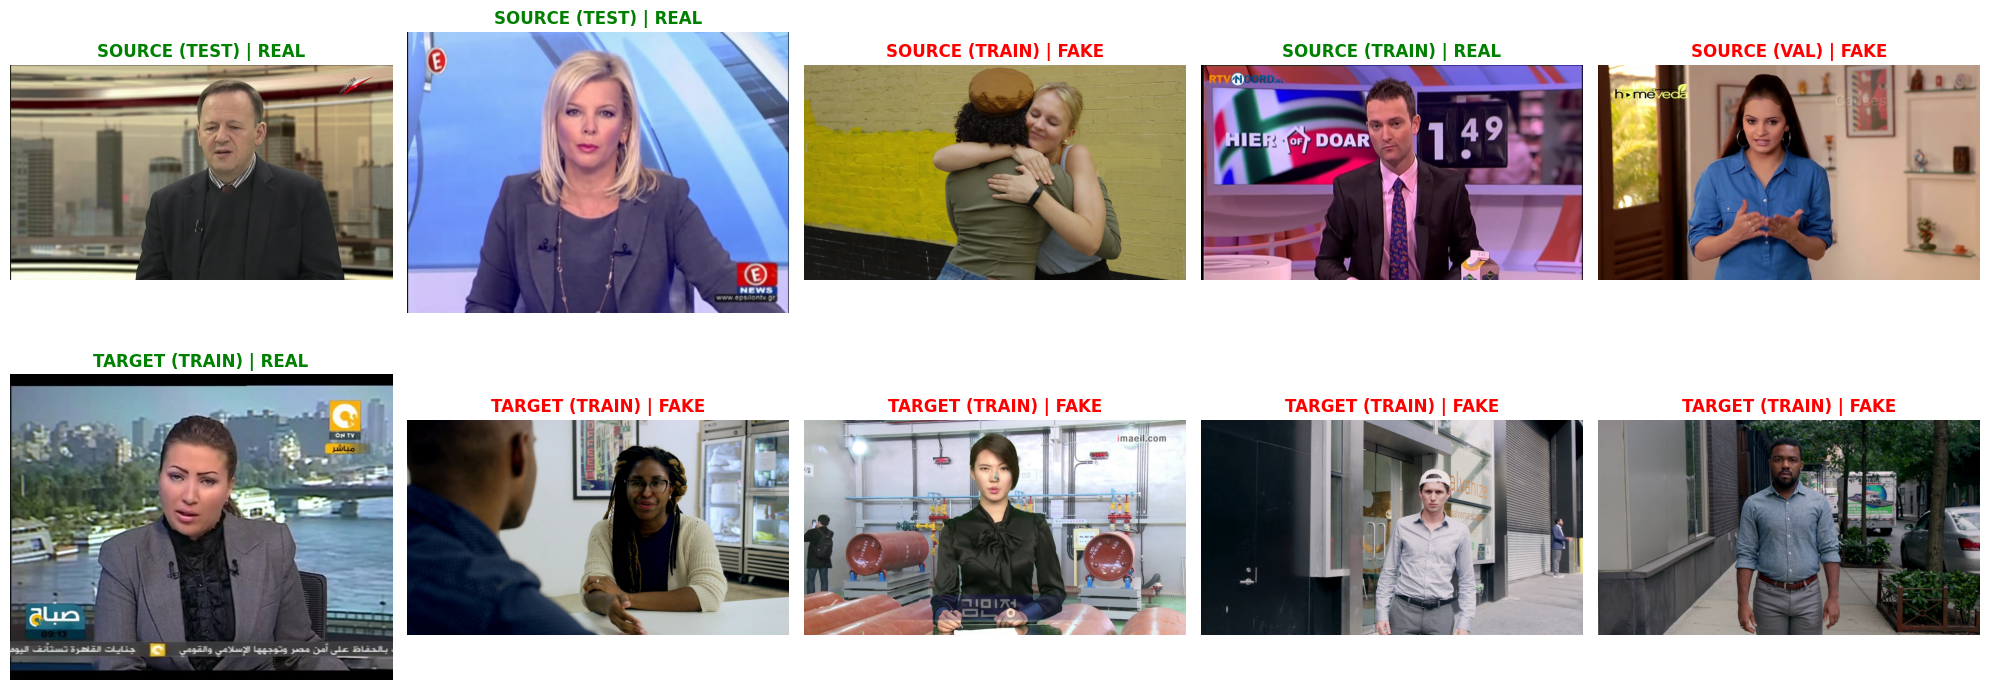

In [69]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

def get_random_frames(base_path, num_images, split_type):
    """Helper function to extract N random frames from a specific folder."""
    all_frames = []
    
    if not os.path.exists(base_path):
        return []

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(".jpg"):
                full_path = os.path.join(root, file)
                parts = root.split(os.sep)
                
                subset = parts[-2]  # train, val, or test
                folder_label = parts[-1]  # original or fake
                
                label = "REAL" if folder_label == "original" else "FAKE"
                all_frames.append((full_path, subset, label, split_type))
    
    if not all_frames:
        return []
        
    return random.sample(all_frames, min(num_images, len(all_frames)))

def show_both_splits_frames():
    print("--- VISUALIZING RANDOM FRAMES FROM BOTH SPLITS ---")

    sample_src = get_random_frames("split_source", fpv, "SOURCE")
    sample_trg = get_random_frames("split_target", fpv, "TARGET")
    
    sample = sample_src + sample_trg
    
    if not sample:
        print("No images found...")
        return 

    cols = 5
    rows = 2
    plt.figure(figsize=(20, 4 * rows))

    for i, (img_path, subset, label, split_type) in enumerate(sample):
        plt.subplot(rows, cols, i+1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.axis('off')

        title_color = 'green' if label == "REAL" else 'red'
        plt.title(f"{split_type} ({subset.upper()}) | {label}", color=title_color, fontweight='bold')

    plt.tight_layout()
    plt.show()

show_both_splits_frames()